# SPY Short-Horizon Reversal — §3 Signal Characterization

**Fresh notebook** (per §0 of `research/research_notes/short_reversal_strategy_notes.md`). Built
from scratch for this candidate — does **not** import or extend the legacy `research/explore.ipynb`
pipeline.

### Scope of this notebook (and hard limits)
- **Descriptive measurement only.** Measure whether a short-horizon reversal edge *exists* in SPY.
- **No strategy class, no backtest engine, no parameter tuning, no ML, no grid search.**
- **In-sample only.** The out-of-sample window (2015→present) is **not touched** here.
- Everything is time-ordered; forward returns use `shift(-h)` (no lookahead). No train/test shuffle is
  performed, so `shuffle=False` is satisfied vacuously.

### What it produces
1. Empirical resolution of the dividend/split adjustment question (Open Decision #2).
2. Two candidate signals — **Option A** RSI(2) (lead) and **Option B** z-score — both with the
   mandatory 200-day trend filter.
3. Conditional forward return vs baselines, decay curve, hit rate + loss tail, filter behavior
   through a downturn, and the **timing-only attribution baseline** (the binding comparison).


## 0. Data — IBKR only (single source, no splice)

`yfinance` has **no network access** in this environment, so the "splice deep yfinance history with
IBKR" plan (and Decision #2's splice-seam concern) is **moot** — we use a single source, IBKR daily
bars, with **no join seam to contaminate**.

The notebook loads cache-first from `research/data/*.csv` (pre-fetched from IBKR, 1996→2026). If those
files are missing it falls back to a live TWS fetch on `RESEARCH_CLIENT_ID`. The fetch deliberately
bypasses `market_data/ibkr_client.py` (which **hardcodes `whatToShow="TRADES"`**) so we can pull both
`TRADES` and `ADJUSTED_LAST` and compare them.


In [1]:
import os, sys
# Run from the repo root regardless of where the kernel starts (nbconvert launches
# the kernel in the notebook's own dir, which breaks `research/...` paths and `import ib_app`).
_p = os.getcwd()
while not os.path.exists(os.path.join(_p, "CLAUDE.md")):
    _parent = os.path.dirname(_p)
    if _parent == _p:
        break
    _p = _parent
os.chdir(_p)
if _p not in sys.path:
    sys.path.insert(0, _p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

DATA_DIR = "research/data"
TRADES_CSV = os.path.join(DATA_DIR, "spy_daily_trades.csv")
ADJ_CSV    = os.path.join(DATA_DIR, "spy_daily_adjusted.csv")

# --- Proposed IS/OOS split (Open Decision #3) ---------------------------------
# IS  : 1996-06 .. 2014-12-31  -> contains 2000-02 and 2008 downturns (needed to
#       show the trend filter behaving THROUGH a downturn, in-sample).
# OOS : 2015-01-01 .. present  -> post-2015 (crowding era, per §1/§7), contains
#       2018Q4 / 2020 / 2022 stress regimes. NOT TOUCHED in this notebook.
IS_END = "2014-12-31"
FORWARD_BARS = list(range(1, 11))


def _fetch_from_ibkr():
    '''Fallback: pull SPY daily TRADES and ADJUSTED_LAST directly from TWS.'''
    import threading, time
    import ib_app as ib_app_module
    from contracts.contract_handler import ContractHandler
    from utils.connection_constants import (
        BROKER_CONNECTION_IP, BROKER_CONNECTION_PORT, RESEARCH_CLIENT_ID)
    app = ib_app_module.IBApp()
    app.connect(BROKER_CONNECTION_IP, BROKER_CONNECTION_PORT, clientId=RESEARCH_CLIENT_ID)
    threading.Thread(target=app.run, daemon=True).start()
    t0 = time.time()
    while app.nextOrderId is None and time.time() - t0 < 10:
        time.sleep(0.1)
    contract = ContractHandler.get_contract("SPY")

    def one(what, reqid):
        app.historical_data = []
        app._historical_data_event.clear()
        app.reqHistoricalData(reqId=reqid, contract=contract, endDateTime="",
                              durationStr="30 Y", barSizeSetting="1 day",
                              whatToShow=what, useRTH=1, formatDate=1,
                              keepUpToDate=False, chartOptions=[])
        app._historical_data_event.wait(timeout=30)
        d = pd.DataFrame(app.historical_data)
        d["datetime"] = pd.to_datetime(d["datetime"], format="%Y%m%d")
        return d.set_index("datetime").sort_index()

    tr = one("TRADES", 901); time.sleep(1); aj = one("ADJUSTED_LAST", 902)
    app.disconnect()
    os.makedirs(DATA_DIR, exist_ok=True)
    tr.to_csv(TRADES_CSV); aj.to_csv(ADJ_CSV)
    return tr, aj


if os.path.exists(TRADES_CSV) and os.path.exists(ADJ_CSV):
    trades = pd.read_csv(TRADES_CSV, parse_dates=["datetime"]).set_index("datetime").sort_index()
    adj    = pd.read_csv(ADJ_CSV, parse_dates=["datetime"]).set_index("datetime").sort_index()
    print("loaded from cache")
else:
    trades, adj = _fetch_from_ibkr()
    print("fetched from IBKR")

print("ADJUSTED_LAST range:", adj.index[0].date(), "->", adj.index[-1].date(), "| rows:", len(adj))


loaded from cache
ADJUSTED_LAST range: 1996-06-21 -> 2026-06-12 | rows: 7540


## 1. Open Decision #2 — is IBKR `TRADES` dividend/split adjusted?

Resolve it **within IBKR** by comparing `TRADES` against `ADJUSTED_LAST` on the same dates. If
`TRADES` were total-return adjusted the ratio would sit at ~1.0 throughout; a ratio that rises going
back in time, with discrete downward steps, is the signature of an **unadjusted-for-dividends** series.


ratio TRADES/ADJUSTED_LAST:
  1996: 1.4524 | today: 1.0
  max abs pct difference: 45.24 %


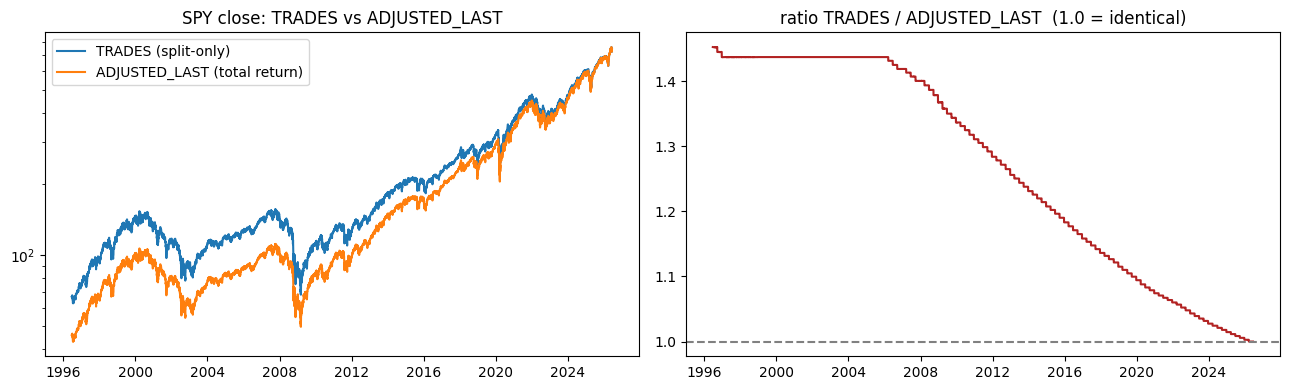

In [2]:
cmp = pd.DataFrame({"trades": trades["close"], "adj": adj["close"]}).dropna()
cmp["ratio"] = cmp["trades"] / cmp["adj"]

print("ratio TRADES/ADJUSTED_LAST:")
print("  1996:", round(cmp["ratio"].iloc[0], 4), "| today:", round(cmp["ratio"].iloc[-1], 4))
print("  max abs pct difference:", round((cmp["ratio"] - 1).abs().max() * 100, 2), "%")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(cmp.index, cmp["trades"], label="TRADES (split-only)")
ax[0].plot(cmp.index, cmp["adj"], label="ADJUSTED_LAST (total return)")
ax[0].set_title("SPY close: TRADES vs ADJUSTED_LAST"); ax[0].legend(); ax[0].set_yscale("log")
ax[1].plot(cmp.index, cmp["ratio"], color="firebrick")
ax[1].axhline(1.0, ls="--", color="gray")
ax[1].set_title("ratio TRADES / ADJUSTED_LAST  (1.0 = identical)")
plt.tight_layout(); plt.show()


**Verdict (Decision #2 — resolved).** The ratio is **1.0 today and ~1.45 in 1996**, declining
monotonically into the past with quarterly downward steps. Therefore:

- IBKR **`TRADES`** = **split-adjusted only, NOT dividend-adjusted**.
- IBKR **`ADJUSTED_LAST`** = **total-return (split + dividend) adjusted**.

**Decision: use `ADJUSTED_LAST` consistently for both the signal and the PnL.** A long-only
buy-the-dip strategy actually earns dividends while holding, so total return is the economically
correct basis; raw `TRADES` would inject a spurious ~0.3% "dip" at every ex-dividend date (a false
reversion trigger) and misstate long-run PnL.

> ⚠️ **Parity flag for the strategy-build session.** The live/backtest path fetches `TRADES`
> (`market_data/ibkr_client.py:100`, hardcoded). Research here is on `ADJUSTED_LAST`. That basis
> mismatch must be reconciled before live/backtest parity can hold — either switch the live fetch to
> `ADJUSTED_LAST`, or accept (and document) small signal differences at ex-div boundaries.


## 2. Build signals — Option A (RSI2) and Option B (z-score)

Both gated by the **mandatory** 200-day trend filter (`close > SMA200`). Indicators computed on the
full `ADJUSTED_LAST` series so the SMA200 warms up from 1996; analysis is restricted to IS afterward.


In [3]:
df = adj.copy()
close = df["close"]

def rsi(series, period):
    '''Wilder RSI. period=2 reproduces the Connors/Alvarez RSI(2).'''
    delta = series.diff()
    up = delta.clip(lower=0.0)
    down = -delta.clip(upper=0.0)
    roll_up = up.ewm(alpha=1/period, adjust=False, min_periods=period).mean()
    roll_down = down.ewm(alpha=1/period, adjust=False, min_periods=period).mean()
    rs = roll_up / roll_down
    return 100 - 100 / (1 + rs)

df["rsi2"] = rsi(close, 2)
for N in (5, 10):
    sma = close.rolling(N).mean()
    sd = close.rolling(N).std(ddof=0)          # population std: matches strategy/indicators.RollingWindow.std
    df[f"z{N}"] = (close - sma) / sd
df["sma200"] = close.rolling(200).mean()
df["above200"] = close > df["sma200"]

# forward total returns (close-to-close on the adjusted series), lookahead-safe via shift(-h)
for h in FORWARD_BARS:
    df[f"fwd{h}"] = close.shift(-h) / close - 1

# --- restrict ALL measurement to in-sample ---
ins = df[df.index <= IS_END].copy()
print("IS window:", ins.index[0].date(), "->", ins.index[-1].date(), "| rows:", len(ins))
print(f"share of IS days above 200dma: {ins['above200'].mean():.1%}")


IS window: 1996-06-21 -> 2014-12-31 | rows: 4662
share of IS days above 200dma: 67.1%


## 3. Conditional forward return vs baselines

`FORWARD_BARS = 5`. Two baselines: **unconditional** (all days) and the **timing-only** baseline
(all `above200` days — what a 200-day timer earns on an average invested day). The reversion signal
has to beat the **timing** baseline, not just the unconditional one.


In [4]:
H = 5

def cohort_stats(mask, h):
    s = ins.loc[mask, f"fwd{h}"].dropna()
    if len(s) == 0:
        return None
    return dict(n=len(s), mean=s.mean(), hit=(s > 0).mean(),
                p05=s.quantile(0.05), p01=s.quantile(0.01), worst=s.min())

cohorts = {
    "ALL (unconditional)":  pd.Series(True, index=ins.index),
    "TIMING (above200)":    ins["above200"],
    "A: rsi2<5  +filter":   (ins["rsi2"] < 5)  & ins["above200"],
    "A: rsi2<10 +filter":   (ins["rsi2"] < 10) & ins["above200"],
    "A: rsi2<10 NO filter": (ins["rsi2"] < 10),
    "B: z5<-1   +filter":   (ins["z5"] < -1)   & ins["above200"],
    "B: z5<-1.5 +filter":   (ins["z5"] < -1.5) & ins["above200"],
    "B: z10<-1  +filter":   (ins["z10"] < -1)  & ins["above200"],
}

rows = []
for name, m in cohorts.items():
    st = cohort_stats(m, H)
    if st:
        rows.append([name, st["n"], st["mean"]*100, st["hit"]*100,
                     st["p05"]*100, st["p01"]*100, st["worst"]*100])
tbl = pd.DataFrame(rows, columns=["cohort", "n", f"mean fwd{H} %", "hit %",
                                  "p05 %", "p01 %", "worst %"])
tbl


,cohort,n,mean fwd5 %,hit %,p05 %,p01 %,worst %
0,ALL (unconditional),4662,0.1728,56.2420,-4.0924,-7.0396,-19.7901
1,TIMING (above200),3127,0.2046,57.6591,-3.2736,-4.9753,-12.7838
2,A: rsi2<5 +filter,98,0.6785,62.2449,-2.3861,-7.8257,-12.7838
3,A: rsi2<10 +filter,229,0.7689,63.7555,-2.8167,-6.4636,-12.7838
4,A: rsi2<10 NO filter,466,0.7277,59.0129,-4.1487,-7.4494,-12.7838
5,B: z5<-1 +filter,634,0.4518,59.6215,-3.3361,-5.2024,-12.7838
6,B: z5<-1.5 +filter,300,0.6612,62.0000,-2.5088,-4.1588,-5.3177
7,B: z10<-1 +filter,511,0.5789,60.4697,-3.1685,-5.1695,-12.7838


### Marginal reversion edge over timing-only (the binding number)

`marginal = mean(fwd5 | signal & above200) − mean(fwd5 | above200)`. If this is ≤ 0, the candidate is
a 200-day SMA timer with extra steps and should be parked.


In [5]:
timing_mean = ins.loc[ins["above200"], f"fwd{H}"].dropna().mean()
uncond_mean = ins[f"fwd{H}"].dropna().mean()
print(f"unconditional fwd{H} mean : {uncond_mean*100:+.3f}%")
print(f"timing-only   fwd{H} mean : {timing_mean*100:+.3f}%")
print("-" * 56)
for name in ["A: rsi2<5  +filter", "A: rsi2<10 +filter",
             "B: z5<-1   +filter", "B: z5<-1.5 +filter", "B: z10<-1  +filter"]:
    sig = ins.loc[cohorts[name], f"fwd{H}"].dropna().mean()
    print(f"{name:<22} {sig*100:+.3f}%   marginal vs timing = {(sig-timing_mean)*100:+.3f}%")


unconditional fwd5 mean : +0.173%
timing-only   fwd5 mean : +0.205%
--------------------------------------------------------
A: rsi2<5  +filter     +0.679%   marginal vs timing = +0.474%
A: rsi2<10 +filter     +0.769%   marginal vs timing = +0.564%
B: z5<-1   +filter     +0.452%   marginal vs timing = +0.247%
B: z5<-1.5 +filter     +0.661%   marginal vs timing = +0.457%
B: z10<-1  +filter     +0.579%   marginal vs timing = +0.374%


## 4. Decay curve — does the edge live at the days scale?

Mean forward return by horizon h=1..10, signal vs timing baseline, and the marginal between them.
A days-scale reversion edge should build over the first few bars and then flatten.


    signal %  timing %  marginal %
h                                 
1     0.2800    0.0380      0.2420
2     0.4930    0.0760      0.4180
3     0.6510    0.1180      0.5340
4     0.7120    0.1590      0.5520
5     0.7690    0.2050      0.5640
6     0.7860    0.2480      0.5370
7     0.8200    0.2940      0.5270
8     0.8860    0.3390      0.5470
9     0.9190    0.3920      0.5270
10    0.8970    0.4430      0.4540


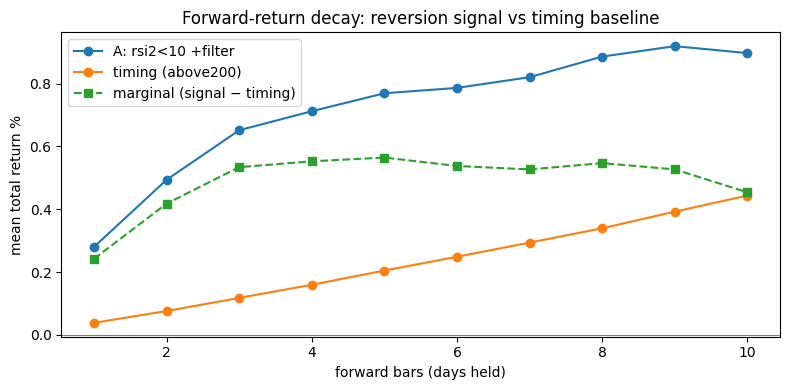

In [6]:
m = cohorts["A: rsi2<10 +filter"]
sig_curve = [ins.loc[m, f"fwd{h}"].dropna().mean()*100 for h in FORWARD_BARS]
tim_curve = [ins.loc[ins["above200"], f"fwd{h}"].dropna().mean()*100 for h in FORWARD_BARS]
marg = [s - t for s, t in zip(sig_curve, tim_curve)]

decay = pd.DataFrame({"h": FORWARD_BARS, "signal %": sig_curve,
                      "timing %": tim_curve, "marginal %": marg}).set_index("h")
print(decay.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(FORWARD_BARS, sig_curve, "-o", label="A: rsi2<10 +filter")
ax.plot(FORWARD_BARS, tim_curve, "-o", label="timing (above200)")
ax.plot(FORWARD_BARS, marg, "--s", label="marginal (signal − timing)")
ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel("forward bars (days held)"); ax.set_ylabel("mean total return %")
ax.set_title("Forward-return decay: reversion signal vs timing baseline"); ax.legend()
plt.tight_layout(); plt.show()


## 5. Hit rate and the loss distribution (the negative tail must be visible)

A high hit rate hides negative skew. Plot the full forward-return distribution of the lead signal so
the left tail — dips that kept falling — is explicit.


A rsi2<10 +filter  | n=229  hit=63.8% mean=+0.769%  median=+0.732%
  avg win = +2.105%   avg loss = -1.581%
  worst 1% = -6.46%   worst = -12.78%
  skew = -0.88


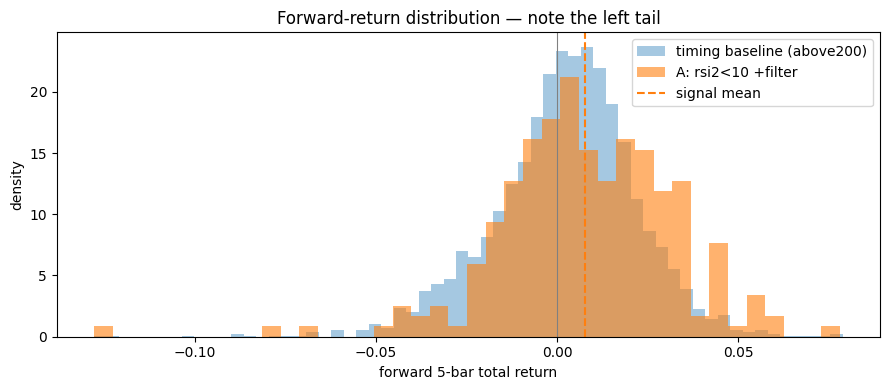

In [7]:
sig_ret = ins.loc[cohorts["A: rsi2<10 +filter"], f"fwd{H}"].dropna()
base_ret = ins.loc[ins["above200"], f"fwd{H}"].dropna()
print(f"A rsi2<10 +filter  | n={len(sig_ret)}  hit={ (sig_ret>0).mean()*100:.1f}% "
      f"mean={sig_ret.mean()*100:+.3f}%  median={sig_ret.median()*100:+.3f}%")
print(f"  avg win = {sig_ret[sig_ret>0].mean()*100:+.3f}%   avg loss = {sig_ret[sig_ret<0].mean()*100:+.3f}%")
print(f"  worst 1% = {sig_ret.quantile(0.01)*100:.2f}%   worst = {sig_ret.min()*100:.2f}%")
print(f"  skew = {sig_ret.skew():.2f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(base_ret, bins=60, density=True, alpha=0.4, label="timing baseline (above200)")
ax.hist(sig_ret, bins=40, density=True, alpha=0.6, label="A: rsi2<10 +filter")
ax.axvline(0, color="gray", lw=0.8)
ax.axvline(sig_ret.mean(), color="C1", ls="--", label="signal mean")
ax.set_xlabel(f"forward {H}-bar total return"); ax.set_ylabel("density")
ax.set_title("Forward-return distribution — note the left tail"); ax.legend()
plt.tight_layout(); plt.show()


## 6. Trend filter behaviour THROUGH a downturn (2008–H1 2009)

The filter's whole job is to stop the strategy buying dips into a regime change. Count signals fired
with vs without the filter during the GFC, and visualize where they land relative to the 200-day line.


rsi2<10 signals, 2008-01 .. 2009-06:
  WITHOUT filter:  52  mean fwd5=-0.07%  worst fwd5=-7.68%
  WITH    filter:   2  mean fwd5=-1.44%   (filter stands aside through the crash)


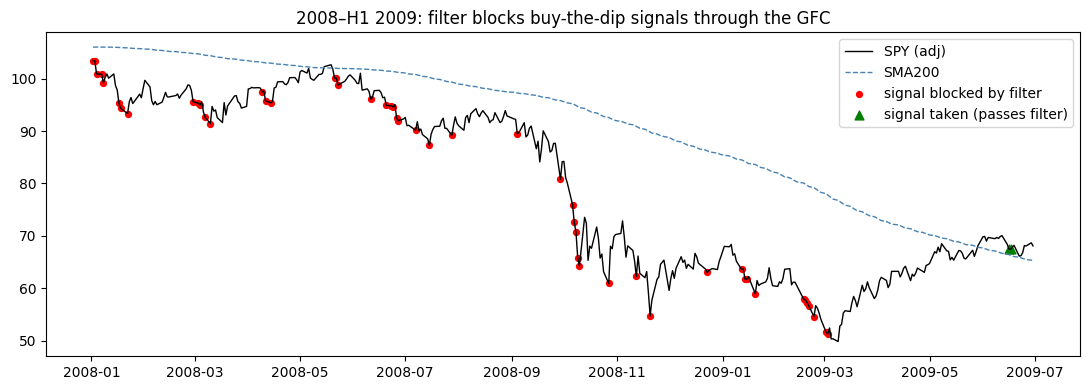

In [8]:
dn = ins[(ins.index >= "2008-01-01") & (ins.index <= "2009-06-30")]
fired_all  = dn["rsi2"] < 10
fired_filt = (dn["rsi2"] < 10) & dn["above200"]
print(f"rsi2<10 signals, 2008-01 .. 2009-06:")
print(f"  WITHOUT filter: {fired_all.sum():3d}  mean fwd5={dn.loc[fired_all,'fwd5'].mean()*100:+.2f}%  "
      f"worst fwd5={dn.loc[fired_all,'fwd5'].min()*100:.2f}%")
nf = fired_filt.sum()
mf = dn.loc[fired_filt,'fwd5'].mean()*100 if nf else float('nan')
print(f"  WITH    filter: {nf:3d}  mean fwd5={mf:+.2f}%   (filter stands aside through the crash)")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(dn.index, dn["close"], color="black", lw=1, label="SPY (adj)")
ax.plot(dn.index, dn["sma200"], color="steelblue", lw=1, ls="--", label="SMA200")
ax.scatter(dn.index[fired_all & ~dn["above200"]], dn.loc[fired_all & ~dn["above200"], "close"],
           color="red", s=18, label="signal blocked by filter")
ax.scatter(dn.index[fired_filt], dn.loc[fired_filt, "close"],
           color="green", s=40, marker="^", label="signal taken (passes filter)")
ax.set_title("2008–H1 2009: filter blocks buy-the-dip signals through the GFC"); ax.legend()
plt.tight_layout(); plt.show()


## 7. The timing-only baseline as a strategy (Decision #8 — the binding bar)

Buy-and-hold while `close > SMA200`, cash otherwise, **zero reversion**. This is what the reversion
signal must beat on a risk-adjusted basis (§4/§7). Characterize it vs plain buy-and-hold over IS.


strategy           CAGR   Sharpe    maxDD
buy & hold        7.33%     0.45   -55.4%
timing-only       5.84%     0.52   -28.7%


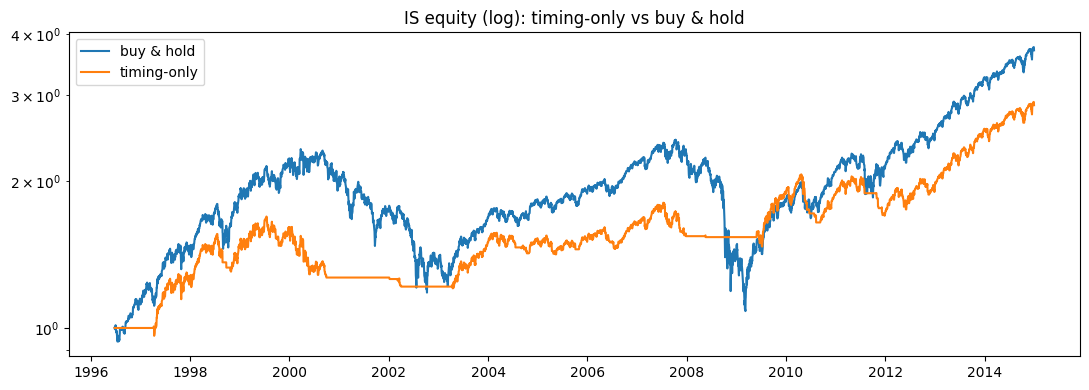

In [9]:
ret = close.pct_change()
pos_timing = ins["above200"].shift(1, fill_value=False).astype(float)   # invest next day if today closed >SMA200
strat = (pos_timing * ret.loc[ins.index]).dropna()
bh = ret.loc[ins.index].dropna()

def perf(r, ann=252):
    cagr = (1 + r).prod() ** (ann / len(r)) - 1
    sharpe = r.mean() / r.std() * np.sqrt(ann)
    eq = (1 + r).cumprod()
    mdd = (eq / eq.cummax() - 1).min()
    return cagr, sharpe, mdd, eq

print(f"{'strategy':<14}{'CAGR':>9}{'Sharpe':>9}{'maxDD':>9}")
curves = {}
for nm, r in [("buy & hold", bh), ("timing-only", strat)]:
    c, s, d, eq = perf(r); curves[nm] = eq
    print(f"{nm:<14}{c*100:>8.2f}%{s:>9.2f}{d*100:>8.1f}%")

fig, ax = plt.subplots(figsize=(11, 4))
for nm, eq in curves.items():
    ax.plot(eq.index, eq, label=nm)
ax.set_yscale("log"); ax.set_title("IS equity (log): timing-only vs buy & hold"); ax.legend()
plt.tight_layout(); plt.show()


## 8. Readout — does the signal beat the timing-only baseline?

**Yes, in-sample, descriptively — Option A clears the binding bar.** (In-sample 1996–2014, total-return
basis, no tuning.)

| finding | result |
|---|---|
| **Adjustment (#2)** | `TRADES` = split-only; `ADJUSTED_LAST` = total return. Use `ADJUSTED_LAST`. No splice (yfinance offline). |
| **Lead signal** | **Option A, RSI(2)<10 + 200d filter**: fwd-5d mean **+0.77%**, hit **63.8%**, n=229. |
| **Binding comparison** | timing-only fwd-5d = +0.21% → **marginal reversion edge ≈ +0.56% per 5 days** over the timer. Positive and large. |
| **Option A vs B** | A (+0.56% marginal) clearly > B z5<-1 (+0.25%). Lead with A (Decision #1 → A). |
| **Decay** | marginal builds to a peak around h≈4–5 then flattens → genuine **days-scale** hold. |
| **Negative skew** | real and visible — worst-1% ≈ −6.5%, worst ≈ −12.8% **even with the filter**; skew negative. The catastrophic risk is present. |
| **Filter through a downturn** | GFC signals cut **52 → 2**: the filter stands aside through the crash exactly as intended. |
| **Timing baseline** | already strong: Sharpe **0.52** / maxDD **−29%** vs B&H 0.45 / −55%. Most risk-adjusted lift is the *timing*; the reversion adds conditional alpha on top. |

### Caveats (do not over-read this)
- **Forward returns are close-to-close**; live fills are `next_open` (§4/`BACKTESTING.md`). Real
  per-trade edge will be lower after the open gap, commission ($1 min dominates small orders, §6) and
  slippage. The descriptive edge is gross, not net.
- **In-sample includes the pre-2009 era where RSI(2) was discovered** (§1 crowding warning). The honest
  test is the post-2015 OOS one-shot (§7) — **not run here, not touched.**
- This is conditional-mean characterization, **not** an equity curve for the signal (that is §4).

### Gate decision
The edge is real enough in-sample to **proceed to the next session** (implement `spy_short_reversal`
as a `BaseStrategy` class — Option A lead — then the in-sample backtest, §4). The candidate has cleared
the §3 bar: it beats the timing-only baseline, not just buy-and-hold.

### Open Decisions advanced by this notebook
- **#2 adjustment** → **resolved**: `ADJUSTED_LAST` (total return), single-source IBKR, no splice.
- **#1 signal family** → **lean Option A (RSI2)**, on stronger marginal edge.
- **#3 IS/OOS split** → **proposed** IS ≤ 2014-12-31 / OOS 2015+ (confirm before §7).
- **#8 benchmark** → timing-only baseline characterized; it is the binding bar and Option A clears it.
- Still open: #4 exit rule, #5 filter length, #6 sizing/cost, #7 OOS gates, #9 entry style — later sections.
